Load data from kaggle

In [1]:
!pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andrewmvd/lung-and-colon-cancer-histopathological-images")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'lung-and-colon-cancer-histopathological-images' dataset.
Path to dataset files: /kaggle/input/lung-and-colon-cancer-histopathological-images


In [2]:
# ===============================
# INSTALLATION INSTRUCTIONS:
# Run these commands in your terminal/command prompt before running the code:
#
# pip install opencv-python
# pip install pillow
# pip install tensorflow
# pip install scikit-learn
# pip install pennylane
# pip install qiskit
# pip install grad-cam
# pip install psutil
# pip install keras-flops
#
# Alternative: Install all at once:
# !pip install opencv-python pillow tensorflow scikit-learn pennylane qiskit grad-cam psutil keras-flops
!pip install pennylane qiskit grad-cam psutil

# ===============================

# ===============================
# Computer Vision
# ===============================
import cv2
from PIL import Image

# ===============================
# TensorFlow / Keras
# ===============================
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)

from tensorflow.keras.applications import (
    VGG16,
    ResNet50
)

from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator
)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

# ===============================
# Dataset splitting
# ===============================
from sklearn.model_selection import train_test_split

# ===============================
# Feature reduction
# ===============================
from sklearn.decomposition import PCA

# ===============================
# Evaluation metrics
# ===============================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ===============================
# Classical comparison models
# ===============================
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# ===============================
# Quantum libraries
# ===============================
import pennylane as qml
from pennylane import numpy as pnp

from qiskit import QuantumCircuit

# ===============================
# Explainability (Grad-CAM)
# ===============================
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# ===============================
# Computational analysis
# ===============================
import psutil
# from keras_flops import get_flops

print("All libraries loaded successfully")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 48.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 40.1 MB/s eta 0:00:00
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=4428

In [3]:
import os
import pandas as pd

lung_path = os.path.join(
    path,
    "lung_colon_image_set",
    "lung_image_sets"
)

# ====================================
# Read all image paths + labels
# ====================================

data = []

classes = {
    "lung_aca":0,
    "lung_n":1,
    "lung_scc":2
}

for class_name, label in classes.items():

    class_folder = os.path.join(
        lung_path,
        class_name
    )

    for img in os.listdir(class_folder):

        img_path = os.path.join(
            class_folder,
            img
        )

        data.append(
            [img_path, label, class_name]
        )

# Create dataframe
df = pd.DataFrame(
    data,
    columns=["path","label","class"]
)

print("Total images:",len(df))
print()
print(df["class"].value_counts())


# ====================================
# 70% Train
# 15% Validation
# 15% Test
# ====================================

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

# ====================================
# Check split sizes
# ====================================

print("\nTrain size:",len(train_df))
print("Validation size:",len(val_df))
print("Test size:",len(test_df))

print("\nTrain distribution")
print(train_df["class"].value_counts())

print("\nValidation distribution")
print(val_df["class"].value_counts())

print("\nTest distribution")
print(test_df["class"].value_counts())

Total images: 15000

class
lung_aca    5000
lung_n      5000
lung_scc    5000
Name: count, dtype: int64

Train size: 10500
Validation size: 2250
Test size: 2250

Train distribution
class
lung_scc    3500
lung_n      3500
lung_aca    3500
Name: count, dtype: int64

Validation distribution
class
lung_aca    750
lung_n      750
lung_scc    750
Name: count, dtype: int64

Test distribution
class
lung_scc    750
lung_n      750
lung_aca    750
Name: count, dtype: int64


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# =====================================
# Train augmentation
# =====================================

train_datagen = ImageDataGenerator(
    rescale=1./255,

    rotation_range=30,
    zoom_range=0.2,

    width_shift_range=0.1,
    height_shift_range=0.1,

    horizontal_flip=True,
    vertical_flip=True
)

# =====================================
# Validation/Test
# (no augmentation)
# =====================================

test_datagen = ImageDataGenerator(
    rescale=1./255
)

# =====================================
# Training generator
# =====================================

training_set = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='path',
    y_col='class',

    target_size=(224,224),
    batch_size=32,

    class_mode='categorical',
    shuffle=True
)

# =====================================
# Validation generator
# =====================================

validation_set = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='path',
    y_col='class',

    target_size=(224,224),
    batch_size=32,

    class_mode='categorical',
    shuffle=False
)

# =====================================
# Test generator
# =====================================

test_set = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col='class',

    target_size=(224,224),
    batch_size=32,

    class_mode='categorical',
    shuffle=False
)

Found 10500 validated image filenames belonging to 3 classes.
Found 2250 validated image filenames belonging to 3 classes.
Found 2250 validated image filenames belonging to 3 classes.


Load pre-trained ImageNet models

In [44]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam

# ====================================
# Load pretrained VGG16
# ====================================

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# ====================================
# Freeze earlier layers
# Fine-tune only final VGG block
# ====================================

for layer in base_model.layers[:-4]:
    layer.trainable = False

for layer in base_model.layers[-4:]:
    layer.trainable = True


# ====================================
# Add custom classifier
# ====================================

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    512,
    activation='relu'
)(x)

x = Dropout(0.5)(x)

output = Dense(
    3,
    activation='softmax'
)(x)

vgg_model = Model(
    inputs=base_model.input,
    outputs=output
)

# ====================================
# Compile
# Lower LR for fine-tuning
# ====================================

vgg_model.compile(
    optimizer=Adam(
        learning_rate=1e-5
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ====================================
# Check trainable layers
# ====================================

for layer in vgg_model.layers:
    print(
        layer.name,
        layer.trainable
    )

vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
input_layer_1 False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True
global_average_pooling2d True
dense_3 True
dropout_2 True
dense_4 True


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,978,883 (57.14 MB)

 Trainable params: 7,343,619 (28.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [45]:
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Training with augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,

    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,

    horizontal_flip=True,
    vertical_flip=True
)

# Validation/Test
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [46]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3
)

In [47]:
print(training_set.class_indices)

print(training_set.image_shape)



{'lung_aca': 0, 'lung_n': 1, 'lung_scc': 2}
(224, 224, 3)


In [48]:
import time

start = time.time()

history = vgg_model.fit(
    training_set,
    validation_data=validation_set,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

end = time.time()

print("Training time:", (end-start)/60, "minutes")

Epoch 1/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 202s 596ms/step - accuracy: 0.8596 - loss: 0.3347 - val_accuracy: 0.9547 - val_loss: 0.1154 - learning_rate: 1.0000e-05
Epoch 2/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 193s 585ms/step - accuracy: 0.9458 - loss: 0.1354 - val_accuracy: 0.9604 - val_loss: 0.0959 - learning_rate: 1.0000e-05
Epoch 3/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 190s 578ms/step - accuracy: 0.9580 - loss: 0.1094 - val_accuracy: 0.9591 - val_loss: 0.0937 - learning_rate: 1.0000e-05
Epoch 4/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 191s 581ms/step - accuracy: 0.9651 - loss: 0.0929 - val_accuracy: 0.9782 - val_loss: 0.0577 - learning_rate: 1.0000e-05
Epoch 5/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 191s 581ms/step - accuracy: 0.9667 - loss: 0.0837 - val_accuracy: 0.9804 - val_loss: 0.0486 - learning_rate: 1.0000e-05
Epoch 6/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 192s 585ms/step - accuracy: 0.9731 - loss: 0.0697 - val_accuracy: 0.9836 - val_loss: 0.0446 - learning_rate: 1.0000e-05
Epoch 7/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
vgg_model.save(
    "vgg_lung_model.keras"
)


In [6]:
from tensorflow.keras.models import load_model

vgg_model = load_model(
    "vgg_lung_model.keras"
)

vgg_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,666,123 (113.17 MB)

 Trainable params: 7,343,619 (28.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

 Optimizer params: 14,687,240 (56.03 MB)

71/71 ━━━━━━━━━━━━━━━━━━━━ 42s 403ms/step
Accuracy : 0.9835555555555555
Precision: 0.9839080459770114
Recall   : 0.9835555555555555
F1-score : 0.983550986385107

Classification Report:

              precision    recall  f1-score   support

    lung_aca       0.99      0.96      0.97       750
      lung_n       1.00      1.00      1.00       750
    lung_scc       0.96      0.99      0.98       750

    accuracy                           0.98      2250
   macro avg       0.98      0.98      0.98      2250
weighted avg       0.98      0.98      0.98      2250



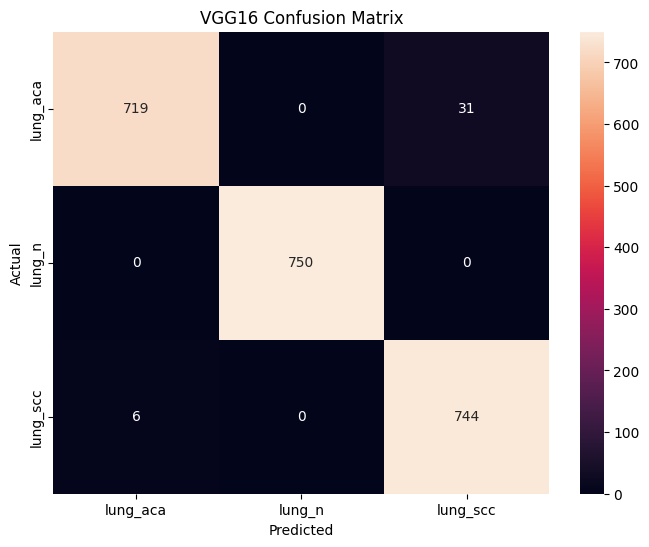

In [7]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ===================================
# Predictions
# ===================================

pred_probs = vgg_model.predict(test_set)

pred_classes = np.argmax(
    pred_probs,
    axis=1
)

true_classes = test_set.classes

class_names = list(
    test_set.class_indices.keys()
)

# ===================================
# Metrics
# ===================================

accuracy_vgg = accuracy_score(
    true_classes,
    pred_classes
)

precision_vgg = precision_score(
    true_classes,
    pred_classes,
    average='weighted'
)

recall_vgg = recall_score(
    true_classes,
    pred_classes,
    average='weighted'
)

f1_vgg = f1_score(
    true_classes,
    pred_classes,
    average='weighted'
)

print("Accuracy :",accuracy_vgg)
print("Precision:",precision_vgg)
print("Recall   :",recall_vgg)
print("F1-score :",f1_vgg)


# ===================================
# Detailed report
# ===================================

print("\nClassification Report:\n")

print(
    classification_report(
        true_classes,
        pred_classes,
        target_names=class_names
    )
)

# ===================================
# Confusion Matrix
# ===================================

cm = confusion_matrix(
    true_classes,
    pred_classes
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("VGG16 Confusion Matrix")

plt.show()

In [49]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam

# ====================================
# Load pretrained ResNet50
# ====================================

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# ====================================
# Freeze most layers
# Fine-tune last ~20 layers
# ====================================

for layer in base_model.layers[:-20]:
    layer.trainable = False

for layer in base_model.layers[-20:]:
    layer.trainable = True


# ====================================
# Add custom classifier
# ====================================

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    512,
    activation='relu'
)(x)

x = Dropout(0.5)(x)

output = Dense(
    3,
    activation='softmax'
)(x)

resnet_model = Model(
    inputs=base_model.input,
    outputs=output
)

# ====================================
# Compile
# Use low LR for fine tuning
# ====================================

resnet_model.compile(
    optimizer=Adam(
        learning_rate=1e-5
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ====================================
# Check trainable layers
# ====================================

for layer in resnet_model.layers:
    print(
        layer.name,
        layer.trainable
    )

resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
input_layer_2 False
conv1_pad False
conv1_conv False
conv1_bn False
conv1_relu False
pool1_pad False
pool1_pool False
conv2_block1_1_conv False
conv2_block1_1_bn False
conv2_block1_1_relu False
conv2_block1_2_conv False
conv2_block1_2_bn False
conv2_block1_2_relu False
conv2_block1_0_conv False
conv2_block1_3_conv False
conv2_block1_0_bn False
conv2_block1_3_bn False
conv2_block1_add False
conv2_block1_out False
conv2_block2_1_conv False
conv2_block2_1_bn False
conv2_block2_1_relu False
conv2_block2_2_conv False
conv2_block2_2_bn False
conv2_block2_2_relu False
conv2_block2_3_conv False
conv2_block2_3_bn False
conv2_block2_add False
conv2_block2_out False
conv2_block3_1_conv False
conv2_block3_1_bn False
conv2_block3_1_relu False
conv2_block3_2_conv False
conv2_block3_2_bn False
conv2_block3_2_relu False
conv2_block3_3_conv False
conv2_block3_3_bn False
conv2_block3_add False
conv2_block3_out False
conv3_block1_1_conv False
conv3_block

Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,638,339 (93.99 MB)

 Trainable params: 9,981,955 (38.08 MB)

 Non-trainable params: 14,656,384 (55.91 MB)

In [50]:
import time

early_stop=EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr=ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3
)

start=time.time()

history_resnet=resnet_model.fit(
    training_set,
    validation_data=validation_set,
    epochs=10,
    callbacks=[
        early_stop,
        reduce_lr
    ]
)

end=time.time()

print(
    "Training time:",
    (end-start)/60,
    "minutes"
)

Epoch 1/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 232s 646ms/step - accuracy: 0.7072 - loss: 0.6368 - val_accuracy: 0.3342 - val_loss: 1.0765 - learning_rate: 1.0000e-05
Epoch 2/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 187s 568ms/step - accuracy: 0.8280 - loss: 0.4060 - val_accuracy: 0.8707 - val_loss: 0.3255 - learning_rate: 1.0000e-05
Epoch 3/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 178s 541ms/step - accuracy: 0.8467 - loss: 0.3579 - val_accuracy: 0.7249 - val_loss: 0.5964 - learning_rate: 1.0000e-05
Epoch 4/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 176s 535ms/step - accuracy: 0.8544 - loss: 0.3365 - val_accuracy: 0.8840 - val_loss: 0.2732 - learning_rate: 1.0000e-05
Epoch 5/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 176s 536ms/step - accuracy: 0.8641 - loss: 0.3222 - val_accuracy: 0.7387 - val_loss: 0.6525 - learning_rate: 1.0000e-05
Epoch 6/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 174s 530ms/step - accuracy: 0.8612 - loss: 0.3200 - val_accuracy: 0.8582 - val_loss: 0.3272 - learning_rate: 1.0000e-05
Epoch 7/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
resnet_model.save(
    "resnet_lung_model.keras"
)


In [20]:
from tensorflow.keras.models import load_model

resnet_model = load_model(
    "resnet_lung_model.keras"
)

resnet_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 44,602,251 (170.14 MB)

 Trainable params: 9,981,955 (38.08 MB)

 Non-trainable params: 14,656,384 (55.91 MB)

 Optimizer params: 19,963,912 (76.16 MB)

71/71 ━━━━━━━━━━━━━━━━━━━━ 26s 263ms/step
Accuracy : 0.9
Precision: 0.8988190883190883
Recall : 0.9
F1 : 0.8991671335200747
              precision    recall  f1-score   support

    lung_aca       0.87      0.83      0.85       750
      lung_n       0.95      0.99      0.97       750
    lung_scc       0.88      0.88      0.88       750

    accuracy                           0.90      2250
   macro avg       0.90      0.90      0.90      2250
weighted avg       0.90      0.90      0.90      2250



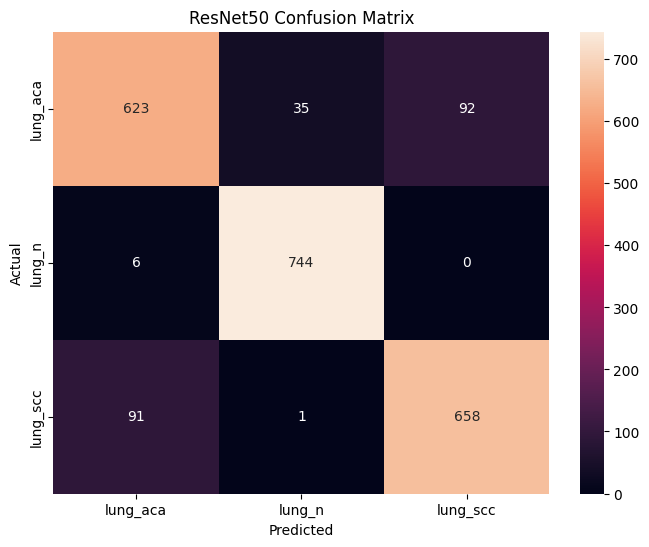

In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# ====================================
# Predictions
# ====================================

pred_probs = resnet_model.predict(
    test_set
)

pred_classes=np.argmax(
    pred_probs,
    axis=1
)

true_classes=test_set.classes

class_names=list(
    test_set.class_indices.keys()
)

# ====================================
# Metrics
# ====================================

accuracy_resnet=accuracy_score(
    true_classes,
    pred_classes
)

precision_resnet=precision_score(
    true_classes,
    pred_classes,
    average='weighted'
)

recall_resnet=recall_score(
    true_classes,
    pred_classes,
    average='weighted'
)

f1_resnet=f1_score(
    true_classes,
    pred_classes,
    average='weighted'
)

print("Accuracy :",accuracy_resnet)
print("Precision:",precision_resnet)
print("Recall :",recall_resnet)
print("F1 :",f1_resnet)

print(
classification_report(
    true_classes,
    pred_classes,
    target_names=class_names
)
)

# ====================================
# Confusion matrix
# ====================================

cm=confusion_matrix(
    true_classes,
    pred_classes
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet50 Confusion Matrix")

plt.show()

AlexNet is not pre-build in keras, so we use the structure and recreate it from scratch

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

alexnet_model = Sequential()

# =====================================
# Layer 1
# =====================================

alexnet_model.add(
    Conv2D(
        filters=96,
        kernel_size=(11,11),
        strides=(4,4),
        activation='relu',
        input_shape=(224,224,3)
    )
)

alexnet_model.add(
    BatchNormalization()
)

alexnet_model.add(
    MaxPooling2D(
        pool_size=(3,3),
        strides=(2,2)
    )
)

# =====================================
# Layer 2
# =====================================

alexnet_model.add(
    Conv2D(
        filters=256,
        kernel_size=(5,5),
        padding='same',
        activation='relu'
    )
)

alexnet_model.add(
    BatchNormalization()
)

alexnet_model.add(
    MaxPooling2D(
        pool_size=(3,3),
        strides=(2,2)
    )
)

# =====================================
# Layer 3
# =====================================

alexnet_model.add(
    Conv2D(
        filters=384,
        kernel_size=(3,3),
        padding='same',
        activation='relu'
    )
)

# =====================================
# Layer 4
# =====================================

alexnet_model.add(
    Conv2D(
        filters=384,
        kernel_size=(3,3),
        padding='same',
        activation='relu'
    )
)

# =====================================
# Layer 5
# =====================================

alexnet_model.add(
    Conv2D(
        filters=256,
        kernel_size=(3,3),
        padding='same',
        activation='relu'
    )
)

alexnet_model.add(
    MaxPooling2D(
        pool_size=(3,3),
        strides=(2,2)
    )
)

# =====================================
# Fully connected layers
# =====================================

alexnet_model.add(Flatten())

alexnet_model.add(
    Dense(
        4096,
        activation='relu'
    )
)

alexnet_model.add(
    Dropout(0.5)
)

alexnet_model.add(
    Dense(
        4096,
        activation='relu'
    )
)

alexnet_model.add(
    Dropout(0.5)
)

# =====================================
# Output layer
# =====================================

alexnet_model.add(
    Dense(
        3,
        activation='softmax'
    )
)

alexnet_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 54, 54, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 26, 26, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │        12,291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,760,707 (178.38 MB)

 Trainable params: 46,760,003 (178.38 MB)

 Non-trainable params: 704 (2.75 KB)

In [23]:
from tensorflow.keras.optimizers import Adam

alexnet_model.compile(
    optimizer=Adam(
        learning_rate=0.0001
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3
)

import time

start=time.time()

history_alex = alexnet_model.fit(
    training_set,
    validation_data=validation_set,
    epochs=10,
    callbacks=[
        early_stop,
        reduce_lr
    ]
)

end=time.time()

print(
    "Training time:",
    (end-start)/60,
    "minutes"
)

Epoch 1/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 197s 562ms/step - accuracy: 0.8826 - loss: 0.3053 - val_accuracy: 0.3333 - val_loss: 8.6753 - learning_rate: 1.0000e-04
Epoch 2/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 161s 490ms/step - accuracy: 0.9275 - loss: 0.1815 - val_accuracy: 0.8040 - val_loss: 0.3743 - learning_rate: 1.0000e-04
Epoch 3/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 163s 496ms/step - accuracy: 0.9365 - loss: 0.1659 - val_accuracy: 0.9049 - val_loss: 0.2431 - learning_rate: 1.0000e-04
Epoch 4/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 181s 550ms/step - accuracy: 0.9350 - loss: 0.1648 - val_accuracy: 0.9196 - val_loss: 0.1887 - learning_rate: 1.0000e-04
Epoch 5/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 170s 517ms/step - accuracy: 0.9499 - loss: 0.1302 - val_accuracy: 0.8373 - val_loss: 0.4587 - learning_rate: 1.0000e-04
Epoch 6/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 164s 498ms/step - accuracy: 0.9543 - loss: 0.1211 - val_accuracy: 0.9311 - val_loss: 0.1543 - learning_rate: 1.0000e-04
Epoch 7/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
alexnet_model.save(
    "AlexNet_lung_model.keras"
)


In [9]:
from tensorflow.keras.models import load_model

alexnet_model = load_model(
    "AlexNet_lung_model.keras"
)

alexnet_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 22 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 54, 54, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 26, 26, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │        12,291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,520,712 (356.75 MB)

 Trainable params: 46,760,003 (178.38 MB)

 Non-trainable params: 704 (2.75 KB)

 Optimizer params: 46,760,005 (178.38 MB)

In [25]:
pred_probs_alex = alexnet_model.predict(
    test_set
)

pred_classes_alex = np.argmax(
    pred_probs_alex,
    axis=1
)

true_classes = test_set.classes


accuracy_alex = accuracy_score(
    true_classes,
    pred_classes_alex
)

precision_alex = precision_score(
    true_classes,
    pred_classes_alex,
    average='weighted'
)

recall_alex = recall_score(
    true_classes,
    pred_classes_alex,
    average='weighted'
)

f1_alex = f1_score(
    true_classes,
    pred_classes_alex,
    average='weighted'
)

print("Accuracy :", accuracy_alex)
print("Precision:", precision_alex)
print("Recall :", recall_alex)
print("F1 :", f1_alex)

print(
    classification_report(
        true_classes,
        pred_classes_alex
    )
)

71/71 ━━━━━━━━━━━━━━━━━━━━ 12s 163ms/step
Accuracy : 0.9564444444444444
Precision: 0.9568835439046911
Recall : 0.9564444444444444
F1 : 0.9564388815568454
              precision    recall  f1-score   support

           0       0.95      0.92      0.93       750
           1       1.00      1.00      1.00       750
           2       0.92      0.95      0.94       750

    accuracy                           0.96      2250
   macro avg       0.96      0.96      0.96      2250
weighted avg       0.96      0.96      0.96      2250



In [26]:
# Example values
alex_acc = accuracy_alex
alex_precision = precision_alex
alex_recall = recall_alex
alex_f1 = f1_alex
# alex_time = alex_training_time

vgg_acc = accuracy_vgg
vgg_precision = precision_vgg
vgg_recall = recall_vgg
vgg_f1 = f1_vgg
# vgg_time = vgg_training_time

resnet_acc = accuracy_resnet
resnet_precision = precision_resnet
resnet_recall = recall_resnet
resnet_f1 = f1_resnet
# resnet_time = resnet_training_time

In [27]:
import pandas as pd

results = pd.DataFrame({

    "Model":[
        "AlexNet",
        "VGG16",
        "ResNet50"
    ],

    "Accuracy":[
        alex_acc,
        vgg_acc,
        resnet_acc
    ],

    "Precision":[
        alex_precision,
        vgg_precision,
        resnet_precision
    ],

    "Recall":[
        alex_recall,
        vgg_recall,
        resnet_recall
    ],

    "F1-score":[
        alex_f1,
        vgg_f1,
        resnet_f1
    ]

})

print(results)

      Model  Accuracy  Precision    Recall  F1-score
0   AlexNet  0.956444   0.956884  0.956444  0.956439
1     VGG16  0.983556   0.983908  0.983556  0.983551
2  ResNet50  0.900000   0.898819  0.900000  0.899167


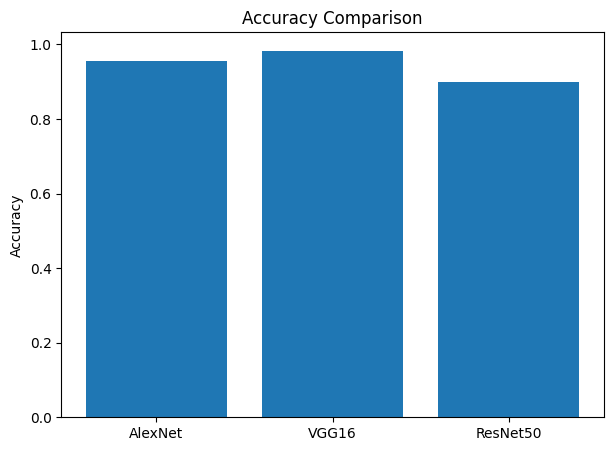

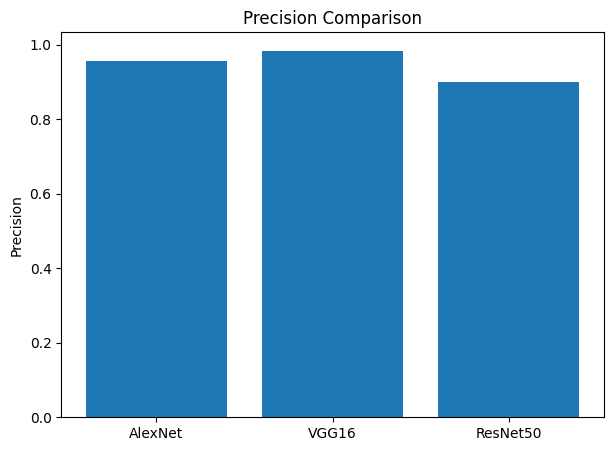

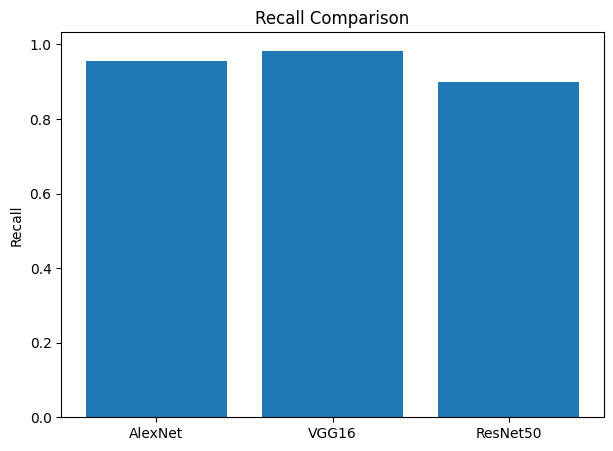

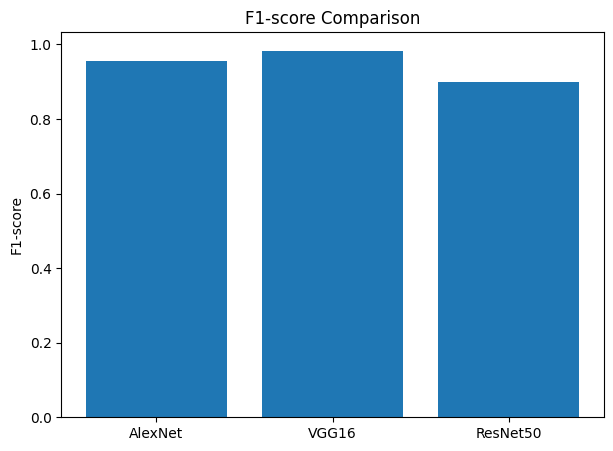

In [28]:
import matplotlib.pyplot as plt

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]

for metric in metrics:

    plt.figure(figsize=(7,5))

    plt.bar(
        results["Model"],
        results[metric]
    )

    plt.title(metric+" Comparison")
    plt.ylabel(metric)

    plt.show()

VGG16 performes the best in almost every case for the lung cancer dataset

In [8]:
# =============================================
# Feature extraction via VGG16
# =============================================
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# New generator with NO shuffle and NO augmentation
extract_datagen = ImageDataGenerator(rescale=1./255)

train_extract = extract_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='path',
    y_col='class',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Feature extractor from VGG16 (layer before classifier)
feature_model = Model(
    inputs=vgg_model.input,
    outputs=vgg_model.layers[-3].output
)

train_features = feature_model.predict(train_extract)
val_features   = feature_model.predict(validation_set)
test_features  = feature_model.predict(test_set)

print("train_features shape:", train_features.shape)
print("test_features shape: ", test_features.shape)

Found 10500 validated image filenames belonging to 3 classes.
329/329 ━━━━━━━━━━━━━━━━━━━━ 112s 337ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 23s 323ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 191ms/step
train_features shape: (10500, 512)
test_features shape:  (2250, 512)


In [9]:
import pennylane as qml
import jax
import jax.numpy as jnp
import numpy as np
import time
# =============================================
# VQC Data Preparation
# PCA on VGG16 features → 4 components
# Full training set — all 10,500 images
# =============================================
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# PCA: 512 VGG16 features → 4 quantum-compatible dims
pca = PCA(n_components=4, random_state=42)
train_pca = pca.fit_transform(train_features)
val_pca   = pca.transform(val_features)
test_pca  = pca.transform(test_features)

# Scale to [-π, π] for angle encoding
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
train_scaled = scaler.fit_transform(train_pca)
val_scaled   = scaler.transform(val_pca)
test_scaled  = scaler.transform(test_pca)

# Labels — from shuffle=False generator, order matches features
y_train = np.array(train_extract.classes)
y_test  = np.array(test_set.classes)

# Full training data as JAX arrays
train_full   = jnp.array(train_scaled, dtype=jnp.float64)
y_train_full = jnp.array(y_train,      dtype=jnp.int32)

print(f"Training features: {train_full.shape}")
print(f"Test features:     {test_scaled.shape}")
print(f"Class distribution: {np.bincount(y_train)}")

/tmp/ipykernel_1539/613029108.py:32: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  train_full   = jnp.array(train_scaled, dtype=jnp.float64)


Training features: (10500, 4)
Test features:     (2250, 4)
Class distribution: [3500 3500 3500]


In [40]:


jax.config.update("jax_enable_x64", True)

n_qubits  = 4
n_layers  = 4
n_classes = 3

dev = qml.device("default.qubit", wires=n_qubits)

# =============================================
# Simple hardware-efficient ansatz
# RY rotations + CNOT entanglement
# This avoids barren plateaus
# =============================================
@qml.qnode(dev, interface='jax', diff_method='backprop')
def quantum_circuit(inputs, weights):

    # --- Encode features ---
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)

    # --- Trainable layers ---
    for layer in range(n_layers):

        # Single-qubit rotations
        for i in range(n_qubits):
            qml.RY(weights[layer, i, 0], wires=i)
            qml.RZ(weights[layer, i, 1], wires=i)

        # Entanglement — simple linear CNOT chain
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i + 1])

    # 3 outputs for 3 classes
    return [qml.expval(qml.PauliZ(i)) for i in range(n_classes)]


# =============================================
# Weight shape: (n_layers, n_qubits, 2)
# Only RY + RZ = 2 params per qubit per layer
# Total: 4 * 4 * 2 = 32 params (tiny!)
# =============================================
key = jax.random.PRNGKey(42)
weights_jax = jax.random.uniform(
    key,
    shape=(n_layers, n_qubits, 2),
    minval=-0.01,
    maxval=0.01,
    dtype=jnp.float64
)

# =============================================
# Forward + loss
# =============================================
def forward(weights, X):
    def single(x):
        logits = jnp.array(quantum_circuit(x, weights))
        return jax.nn.softmax(logits)
    return jax.vmap(single)(X)

def cross_entropy(weights, X, y):
    probs     = forward(weights, X)
    true_prob = probs[jnp.arange(len(y)), y]
    return -jnp.mean(jnp.log(true_prob + 1e-8))

grad_fn  = jax.jit(jax.grad(cross_entropy))
loss_jit = jax.jit(cross_entropy)

# Warm up
print("Compiling...")
_ = grad_fn(weights_jax, train_full[:8], y_train_full[:8])
print("Done.")

Compiling...
Done.


In [41]:
# =============================================
# Circuit — pure JAX
# =============================================
@qml.qnode(dev, interface='jax', diff_method='backprop')
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation='Y')
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_classes)]

# =============================================
# Small weight init — CRITICAL for gradients
# =============================================
key = jax.random.PRNGKey(0)
weights_jax = jax.random.uniform(
    key,
    shape=(n_layers, n_qubits, 3),
    minval=-0.01,
    maxval=0.01,
    dtype=jnp.float64
)

# =============================================
# Batched forward + JIT compiled
# =============================================
def forward(weights, X):
    def single(x):
        logits = jnp.array(quantum_circuit(x, weights))
        return jax.nn.softmax(logits)
    return jax.vmap(single)(X)

def cross_entropy(weights, X, y):
    probs     = forward(weights, X)
    true_prob = probs[jnp.arange(len(y)), y]
    return -jnp.mean(jnp.log(true_prob + 1e-8))

# Compile once — fast from epoch 1 onward
grad_fn  = jax.jit(jax.grad(cross_entropy))
loss_jit = jax.jit(cross_entropy)

# =============================================
# Warm up JIT before timing
# =============================================
print("Compiling... (one-time, ~30s)")
_ = grad_fn(weights_jax, train_full[:8], y_train_full[:8])
print("Done. Starting training.")

Compiling... (one-time, ~30s)
Done. Starting training.


In [42]:
# =============================================
# Training with Adam + LR schedule
# =============================================
lr         = 0.05
epochs     = 50
batch_size = 32

m   = jnp.zeros_like(weights_jax)
v   = jnp.zeros_like(weights_jax)
beta1, beta2, eps_adam = 0.9, 0.999, 1e-8

vqc_hybrid_epoch_losses = []
best_loss    = float('inf')
best_weights = weights_jax
patience     = 15       # early stopping
no_improve   = 0

for epoch in range(epochs):
    losses = []
    t0 = time.time()

    perm   = np.random.permutation(len(train_full))
    X_shuf = train_full[perm]
    y_shuf = y_train_full[perm]

    for i in range(0, len(X_shuf), batch_size):
        X_b = X_shuf[i:i+batch_size]
        y_b = y_shuf[i:i+batch_size]

        grads = grad_fn(weights_jax, X_b, y_b)

        t     = epoch * (len(X_shuf)//batch_size) + i//batch_size + 1
        m     = beta1 * m + (1 - beta1) * grads
        v     = beta2 * v + (1 - beta2) * grads**2
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)

        weights_jax = weights_jax - lr * m_hat / (jnp.sqrt(v_hat) + eps_adam)
        losses.append(float(loss_jit(weights_jax, X_b, y_b)))

    epoch_loss = np.mean(losses)
    vqc_hybrid_epoch_losses.append(epoch_loss)
    elapsed    = time.time() - t0

    # Early stopping
    if epoch_loss < best_loss - 1e-4:
        best_loss    = epoch_loss
        best_weights = weights_jax
        no_improve   = 0
    else:
        no_improve  += 1

    print(f"Epoch {epoch+1:2d}/{epochs}  "
          f"Loss: {epoch_loss:.4f}  "
          f"Best: {best_loss:.4f}  "
          f"({elapsed:.1f}s)")

    if no_improve >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

weights_jax = best_weights
print(f"\nTraining complete. Best loss: {best_loss:.4f}")

Epoch  1/50  Loss: 0.5244  Best: 0.5244  (64.0s)
Epoch  2/50  Loss: 0.4660  Best: 0.4660  (1.6s)
Epoch  3/50  Loss: 0.4404  Best: 0.4404  (1.4s)
Epoch  4/50  Loss: 0.4137  Best: 0.4137  (1.4s)
Epoch  5/50  Loss: 0.4137  Best: 0.4137  (1.4s)
Epoch  6/50  Loss: 0.4132  Best: 0.4132  (1.4s)
Epoch  7/50  Loss: 0.4126  Best: 0.4126  (1.5s)
Epoch  8/50  Loss: 0.4128  Best: 0.4126  (1.7s)
Epoch  9/50  Loss: 0.4123  Best: 0.4123  (1.5s)
Epoch 10/50  Loss: 0.4129  Best: 0.4123  (1.4s)
Epoch 11/50  Loss: 0.4126  Best: 0.4123  (1.5s)
Epoch 12/50  Loss: 0.4128  Best: 0.4123  (2.8s)
Epoch 13/50  Loss: 0.4121  Best: 0.4121  (3.6s)
Epoch 14/50  Loss: 0.4129  Best: 0.4121  (3.5s)
Epoch 15/50  Loss: 0.4124  Best: 0.4121  (2.1s)
Epoch 16/50  Loss: 0.4131  Best: 0.4121  (1.4s)
Epoch 17/50  Loss: 0.4130  Best: 0.4121  (1.4s)
Epoch 18/50  Loss: 0.4129  Best: 0.4121  (1.4s)
Epoch 19/50  Loss: 0.4129  Best: 0.4121  (1.4s)
Epoch 20/50  Loss: 0.4127  Best: 0.4121  (1.4s)
Epoch 21/50  Loss: 0.4123  Best: 0.4121

VQC Accuracy : 0.9782222222222222
VQC Precision: 0.978852320018302
VQC Recall   : 0.9782222222222222
VQC F1-score : 0.9782669145757293

Classification Report:
              precision    recall  f1-score   support

    lung_aca       0.99      0.95      0.97       750
      lung_n       1.00      0.99      1.00       750
    lung_scc       0.95      0.99      0.97       750

    accuracy                           0.98      2250
   macro avg       0.98      0.98      0.98      2250
weighted avg       0.98      0.98      0.98      2250



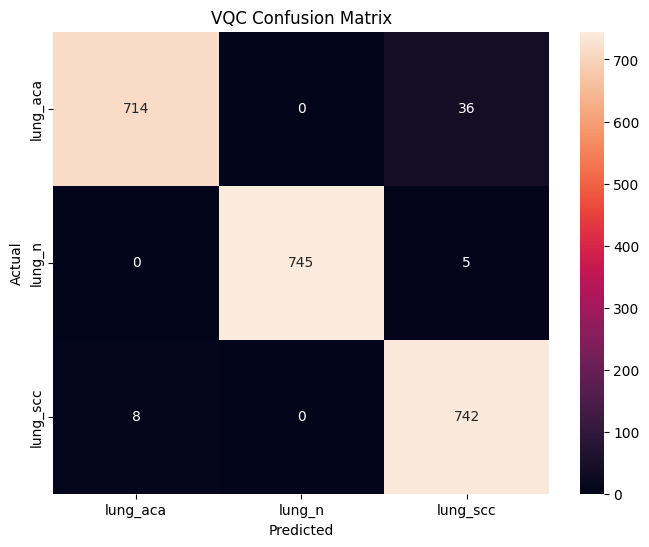

In [13]:
# =============================================
# VQC Evaluation
# =============================================
test_X = jnp.array(test_scaled, dtype=jnp.float64)

probs = np.array(forward(weights_jax, test_X))
preds = np.argmax(probs, axis=1)

class_names = list(test_set.class_indices.keys())

accuracy_vqc  = accuracy_score(y_test, preds)
precision_vqc = precision_score(y_test, preds, average='weighted')
recall_vqc    = recall_score(y_test, preds, average='weighted')
f1_vqc        = f1_score(y_test, preds, average='weighted')

print("VQC Accuracy :", accuracy_vqc)
print("VQC Precision:", precision_vqc)
print("VQC Recall   :", recall_vqc)
print("VQC F1-score :", f1_vqc)

print("\nClassification Report:")
print(classification_report(y_test, preds, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("VQC Confusion Matrix")
plt.show()

     Model  Accuracy  Precision   Recall  F1-score  Parameters
   AlexNet  0.956444   0.956884 0.956444  0.956439         44M
     VGG16  0.983556   0.983908 0.983556  0.983551         29M
  ResNet50  0.900000   0.898819 0.900000  0.899167         46M
Hybrid VQC  0.978222   0.978852 0.978222  0.978267 14M(vgg)+32


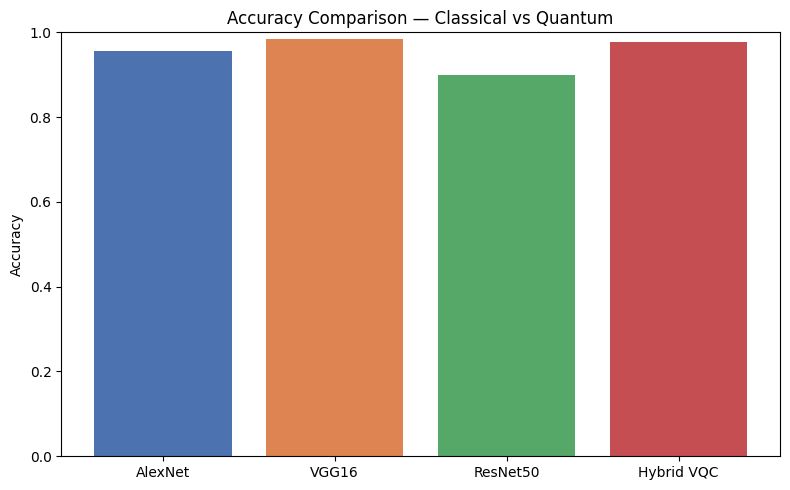

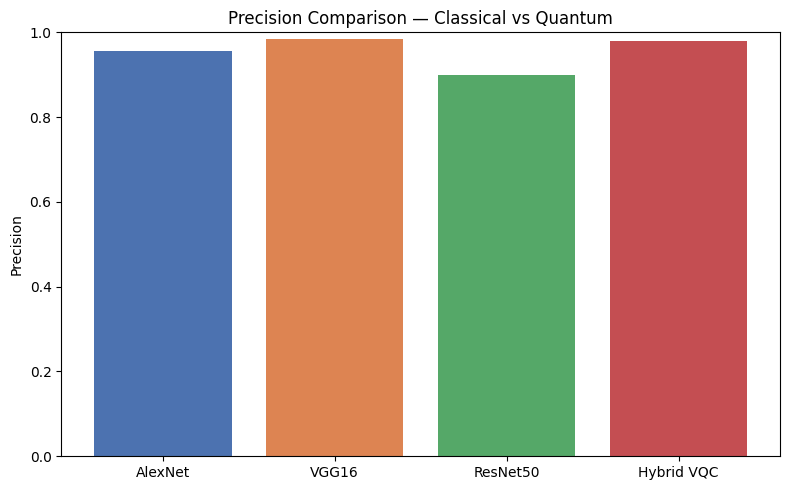

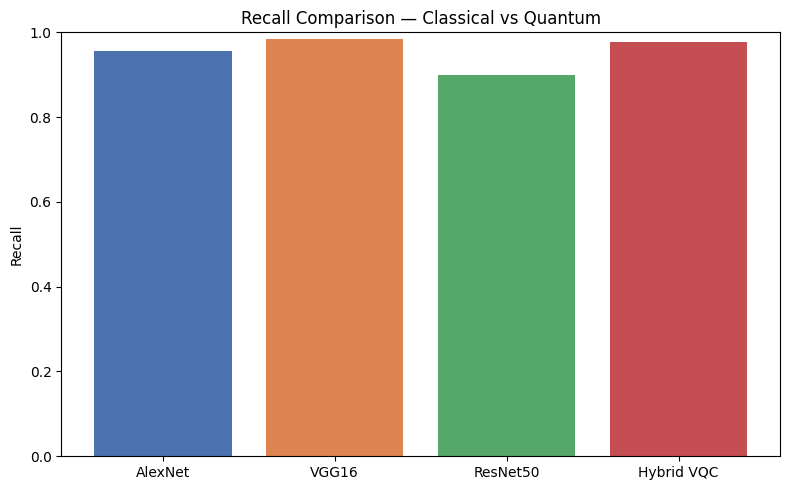

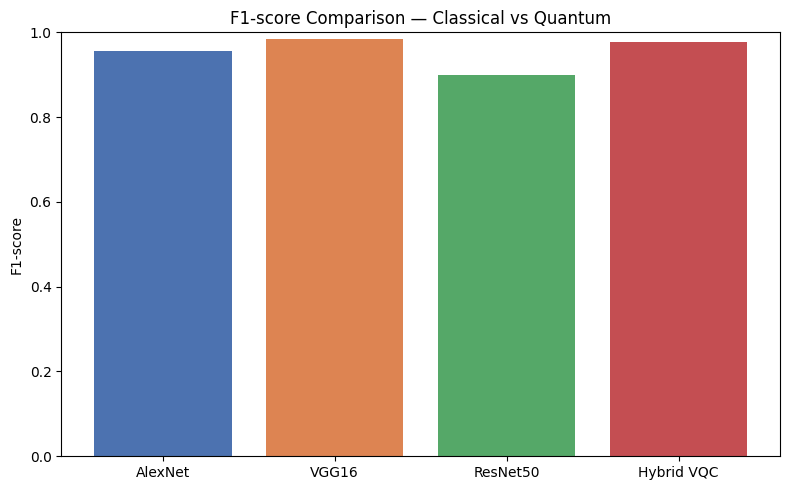

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Model": [
        "AlexNet",
        "VGG16",
        "ResNet50",
        "Hybrid VQC"
    ],
    "Accuracy": [
        alex_acc, vgg_acc, resnet_acc, accuracy_vqc
    ],
    "Precision": [
        alex_precision, vgg_precision, resnet_precision, precision_vqc
    ],
    "Recall": [
        alex_recall, vgg_recall, resnet_recall, recall_vqc
    ],
    "F1-score": [
        alex_f1, vgg_f1, resnet_f1, f1_vqc
    ],
    "Parameters": [
        "44M", "29M", "46M", "14M(vgg)+32"     # key finding for paper
    ]
})

print(results.to_string(index=False))

# Bar charts
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
for metric in metrics:
    plt.figure(figsize=(8, 5))
    plt.bar(results["Model"], results[metric],
            color=["#4C72B0","#DD8452","#55A868","#C44E52"])
    plt.title(f"{metric} Comparison — Classical vs Quantum")
    plt.ylabel(metric)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 202ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 153ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step


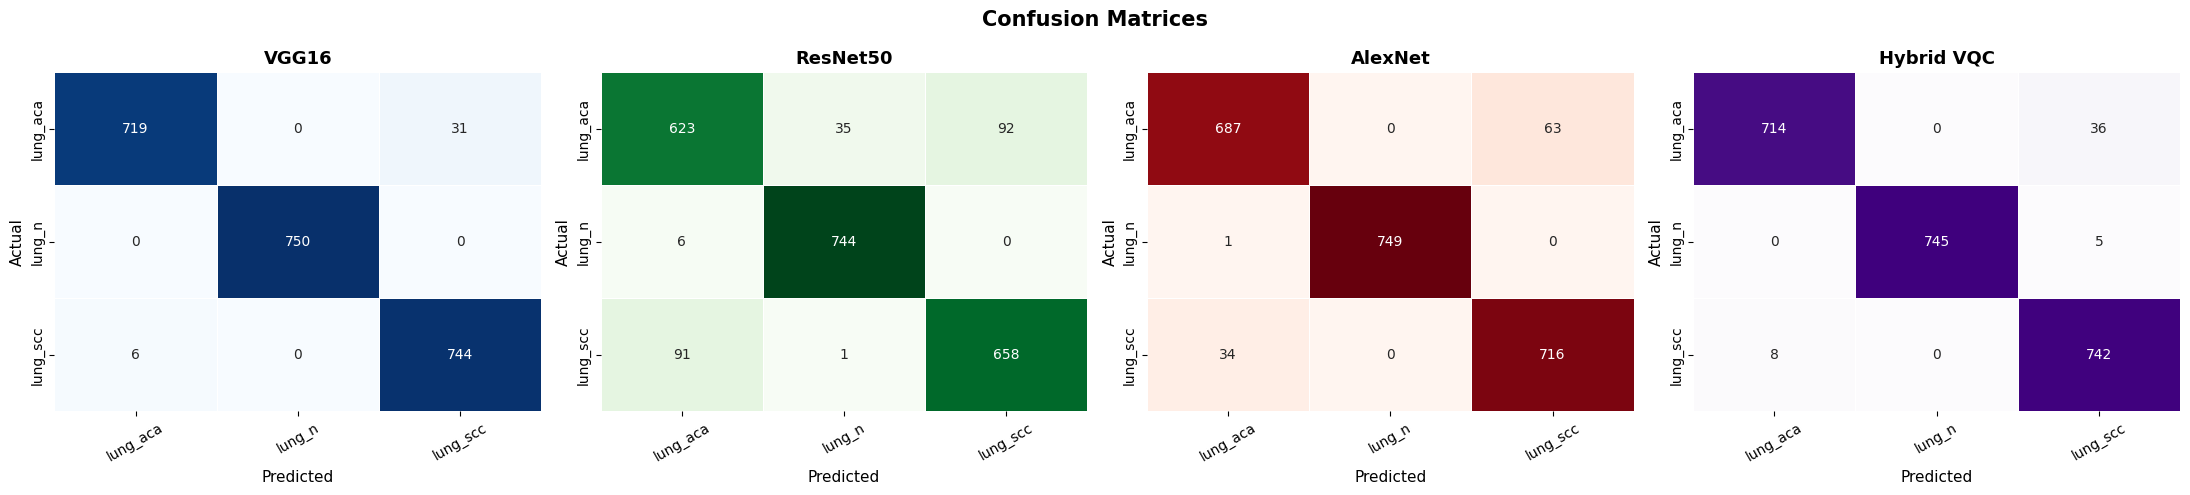

In [30]:
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

class_names = list(test_set.class_indices.keys())

# Recompute confusion matrices
cm_vgg    = confusion_matrix(test_set.classes,  np.argmax(vgg_model.predict(test_set),    axis=1))
cm_resnet = confusion_matrix(test_set.classes,  np.argmax(resnet_model.predict(test_set), axis=1))
cm_alex   = confusion_matrix(test_set.classes,  np.argmax(alexnet_model.predict(test_set),axis=1))

# VQC confusion matrix
test_X_eval   = jnp.array(test_scaled, dtype=jnp.float64)
vqc_probs     = np.array(forward(weights_jax, test_X_eval))
vqc_preds     = np.argmax(vqc_probs, axis=1)
cm_vqc        = confusion_matrix(y_test, vqc_preds)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle("Confusion Matrices", fontsize=15, fontweight='bold')

cms    = [cm_vgg,    cm_resnet,    cm_alex,    cm_vqc]
titles = ["VGG16",   "ResNet50",   "AlexNet",  "Hybrid VQC"]
cmaps  = ["Blues",   "Greens",     "Reds",     "Purples"]

for ax, cm, title, cmap in zip(axes, cms, titles, cmaps):
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=cmap,
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
        linewidths=0.5,
        cbar=False
    )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("Actual", fontsize=11)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

Pure VQC on lung cancer dataset

In [14]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# =============================================
# Load raw images as flat pixel arrays
# No CNN — just resize and flatten
# =============================================
from tensorflow.keras.utils import img_to_array, load_img

def load_flat_images(dataframe, target_size=(64, 64)):
    """
    Loads images, resizes to target_size, flattens to 1D.
    64x64 chosen to keep PCA tractable — still 12,288 dims before PCA.
    """
    images = []
    for path in dataframe['path']:
        img   = load_img(path, target_size=target_size)
        arr   = img_to_array(img) / 255.0   # normalise to [0,1]
        images.append(arr.flatten())
    return np.array(images)

print("Loading training images (this takes a few minutes)...")
train_pixels = load_flat_images(train_df)

print("Loading test images...")
test_pixels  = load_flat_images(test_df)

print(f"train_pixels shape: {train_pixels.shape}")
print(f"test_pixels shape:  {test_pixels.shape}")

Loading training images (this takes a few minutes)...
Loading test images...
train_pixels shape: (10500, 12288)
test_pixels shape:  (2250, 12288)


In [15]:
# =============================================
# Pure VQC Data Preparation → 4 qubits
# PCA: 12,288 raw pixel dims → 4 components
# =============================================
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

n_qubits_pure  = 8
n_layers_pure  = 6

y_train_pure_full = np.array(train_df['label'].values, dtype=np.int32)
y_test_pure       = np.array(test_df['label'].values,  dtype=np.int32)

pca_raw = PCA(n_components=n_qubits_pure, random_state=42)
train_pca_raw = pca_raw.fit_transform(train_pixels)
test_pca_raw  = pca_raw.transform(test_pixels)

print(f"Explained variance per component: {pca_raw.explained_variance_ratio_}")
print(f"Total variance captured: {pca_raw.explained_variance_ratio_.sum():.3f}")

scaler_raw = MinMaxScaler(feature_range=(-np.pi, np.pi))
train_pixels_scaled = scaler_raw.fit_transform(train_pca_raw)
test_pixels_scaled  = scaler_raw.transform(test_pca_raw)

train_pure_full = jnp.array(train_pixels_scaled, dtype=jnp.float64)
y_pure_full     = jnp.array(y_train_pure_full,   dtype=jnp.int32)

print(f"\nPure VQC training: {train_pure_full.shape}")
print(f"Pure VQC test:     {test_pixels_scaled.shape}")
print(f"Class distribution: {np.bincount(y_train_pure_full)}")

Explained variance per component: [0.2458986  0.05602201 0.0159442  0.01338334 0.01175743 0.00909592
 0.00848959 0.00687129]
Total variance captured: 0.367

Pure VQC training: (10500, 8)
Pure VQC test:     (2250, 8)
Class distribution: [3500 3500 3500]


In [16]:
# =============================================
# Pure VQC — independent circuit
# 4 qubits, 4 layers, hardware-efficient ansatz
# Uses its own device + weight variables
# completely separate from hybrid model
# =============================================
import pennylane as qml

dev_pure = qml.device("default.qubit", wires=n_qubits_pure)

@qml.qnode(dev_pure, interface='jax', diff_method='backprop')
def quantum_circuit_pure(inputs, weights):
    # Encode all 4 PCA features
    for i in range(n_qubits_pure):
        qml.RY(inputs[i], wires=i)

    for layer in range(n_layers_pure):
        # Trainable rotations
        for i in range(n_qubits_pure):
            qml.RY(weights[layer, i, 0], wires=i)
            qml.RZ(weights[layer, i, 1], wires=i)
            qml.RX(weights[layer, i, 2], wires=i)

        # Linear CNOT entanglement — avoids barren plateaus
        for i in range(n_qubits_pure):
          qml.CNOT(wires=[i, (i + 1) % n_qubits_pure])

    # 3 measurements for 3 classes
    return [qml.expval(qml.PauliZ(i)) for i in range(3)]


def forward_pure(weights, X):
    def single(x):
        logits = jnp.array(quantum_circuit_pure(x, weights))
        return jax.nn.softmax(logits)
    return jax.vmap(single)(X)

def cross_entropy_pure(weights, X, y):
    probs     = forward_pure(weights, X)
    true_prob = probs[jnp.arange(len(y)), y]
    return -jnp.mean(jnp.log(true_prob + 1e-8))

# Fresh weights — small init critical with 4 qubits
key_pure     = jax.random.PRNGKey(99)
weights_pure = jax.random.uniform(
    key_pure,
    shape=(n_layers_pure, n_qubits_pure, 2),
    minval=-0.01,
    maxval=0.01,
    dtype=jnp.float64
)

grad_fn_pure  = jax.jit(jax.grad(cross_entropy_pure))
loss_jit_pure = jax.jit(cross_entropy_pure)

total_pure_params = n_layers_pure * n_qubits_pure * 2
print(f"Pure VQC parameters: {total_pure_params}")

print("Compiling pure VQC...")
_ = grad_fn_pure(weights_pure, train_pure_full[:8], y_pure_full[:8])
print("Done.")

Pure VQC parameters: 96
Compiling pure VQC...
Done.


In [17]:
# =============================================
# Pure VQC Training — Adam + early stopping
# =============================================
lr_pure    = 0.05
epochs     = 50
batch_size = 32

m_p = jnp.zeros_like(weights_pure)
v_p = jnp.zeros_like(weights_pure)
beta1, beta2, eps_adam = 0.9, 0.999, 1e-8

best_loss_pure    = float('inf')
best_weights_pure = weights_pure
patience_pure     = 5
no_improve_pure   = 0
vqc_pure_epoch_losses = []

for epoch in range(epochs):
    losses = []
    t0     = time.time()

    perm   = np.random.permutation(len(train_pure_full))
    X_shuf = train_pure_full[perm]
    y_shuf = y_pure_full[perm]

    for i in range(0, len(X_shuf), batch_size):
        X_b = X_shuf[i:i+batch_size]
        y_b = y_shuf[i:i+batch_size]

        grads = grad_fn_pure(weights_pure, X_b, y_b)

        t     = epoch * (len(X_shuf)//batch_size) + i//batch_size + 1
        m_p   = beta1 * m_p + (1 - beta1) * grads
        v_p   = beta2 * v_p + (1 - beta2) * grads**2
        m_hat = m_p / (1 - beta1**t)
        v_hat = v_p / (1 - beta2**t)

        weights_pure = weights_pure - lr_pure * m_hat / (jnp.sqrt(v_hat) + eps_adam)
        losses.append(float(loss_jit_pure(weights_pure, X_b, y_b)))

    epoch_loss = np.mean(losses)
    vqc_pure_epoch_losses.append(epoch_loss)
    elapsed    = time.time() - t0

    if epoch_loss < best_loss_pure - 1e-4:
        best_loss_pure    = epoch_loss
        best_weights_pure = weights_pure
        no_improve_pure   = 0
    else:
        no_improve_pure  += 1

    print(f"Epoch {epoch+1:2d}/{epochs}  "
          f"Loss: {epoch_loss:.4f}  "
          f"Best: {best_loss_pure:.4f}  ({elapsed:.1f}s)")

    if no_improve_pure >= patience_pure:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

weights_pure = best_weights_pure
print(f"\nBest loss: {best_loss_pure:.4f}")

Epoch  1/50  Loss: 0.8606  Best: 0.8606  (135.2s)
Epoch  2/50  Loss: 0.7043  Best: 0.7043  (2.2s)
Epoch  3/50  Loss: 0.6905  Best: 0.6905  (2.2s)
Epoch  4/50  Loss: 0.6884  Best: 0.6884  (2.3s)
Epoch  5/50  Loss: 0.6891  Best: 0.6884  (2.1s)
Epoch  6/50  Loss: 0.6960  Best: 0.6884  (2.1s)
Epoch  7/50  Loss: 0.6974  Best: 0.6884  (2.1s)
Epoch  8/50  Loss: 0.6971  Best: 0.6884  (2.1s)
Epoch  9/50  Loss: 0.7046  Best: 0.6884  (2.2s)

Early stopping at epoch 9

Best loss: 0.6884


Pure VQC Accuracy : 0.8022222222222222
Pure VQC Precision: 0.8100715643442403
Pure VQC Recall   : 0.8022222222222222
Pure VQC F1-score : 0.7970219270269694

              precision    recall  f1-score   support

    lung_aca       0.79      0.58      0.67       750
      lung_n       0.95      0.97      0.96       750
    lung_scc       0.69      0.87      0.77       750

    accuracy                           0.80      2250
   macro avg       0.81      0.80      0.80      2250
weighted avg       0.81      0.80      0.80      2250



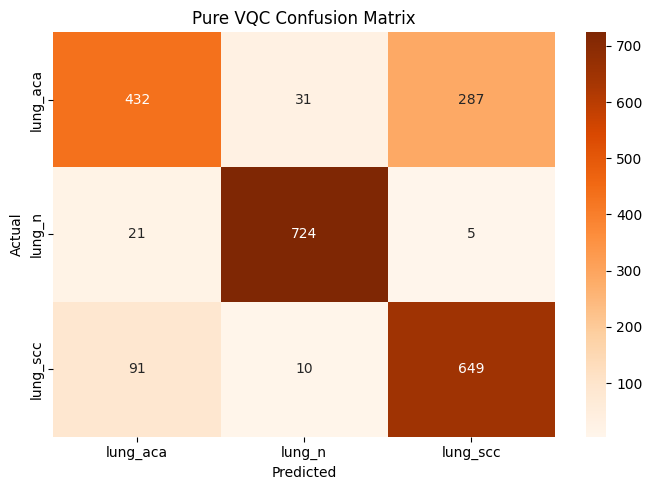

In [18]:
test_pure_X = jnp.array(test_pixels_scaled, dtype=jnp.float64)

probs_pure  = np.array(forward_pure(weights_pure, test_pure_X))
preds_pure  = np.argmax(probs_pure, axis=1)

accuracy_pure  = accuracy_score(y_test_pure,  preds_pure)
precision_pure = precision_score(y_test_pure, preds_pure, average='weighted')
recall_pure    = recall_score(y_test_pure,    preds_pure, average='weighted')
f1_pure        = f1_score(y_test_pure,        preds_pure, average='weighted')

print("Pure VQC Accuracy :", accuracy_pure)
print("Pure VQC Precision:", precision_pure)
print("Pure VQC Recall   :", recall_pure)
print("Pure VQC F1-score :", f1_pure)
print()
print(classification_report(y_test_pure, preds_pure, target_names=class_names))

# Confusion matrix
cm_pure = confusion_matrix(y_test_pure, preds_pure)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_pure, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Pure VQC Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [31]:
results_full = pd.DataFrame({
    "Model": [
        "AlexNet",
        "VGG16",
        "ResNet50",
        "Hybrid VQC\n(VGG16 features)",
        "Pure VQC\n(raw pixels)"
    ],
    "Accuracy":  [alex_acc,  vgg_acc,  resnet_acc,  accuracy_vqc,  accuracy_pure],
    "Precision": [alex_precision, vgg_precision, resnet_precision, precision_vqc, precision_pure],
    "Recall":    [alex_recall,    vgg_recall,    resnet_recall,    recall_vqc,    recall_pure],
    "F1-score":  [alex_f1,        vgg_f1,        resnet_f1,        f1_vqc,        f1_pure],
    "Pretrained":    ["No",    "Yes",   "Yes",   "Yes (VGG16)", "No"],
    "QC params":     ["N/A",   "N/A",   "N/A",   "32",          "32"]
})

print(results_full.to_string(index=False))

                       Model  Accuracy  Precision   Recall  F1-score  Pretrained QC params
                     AlexNet  0.956444   0.956884 0.956444  0.956439          No       N/A
                       VGG16  0.983556   0.983908 0.983556  0.983551         Yes       N/A
                    ResNet50  0.900000   0.898819 0.900000  0.899167         Yes       N/A
Hybrid VQC\n(VGG16 features)  0.978222   0.978852 0.978222  0.978267 Yes (VGG16)        32
      Pure VQC\n(raw pixels)  0.802222   0.810072 0.802222  0.797022          No        32


71/71 ━━━━━━━━━━━━━━━━━━━━ 13s 184ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 156ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 136ms/step


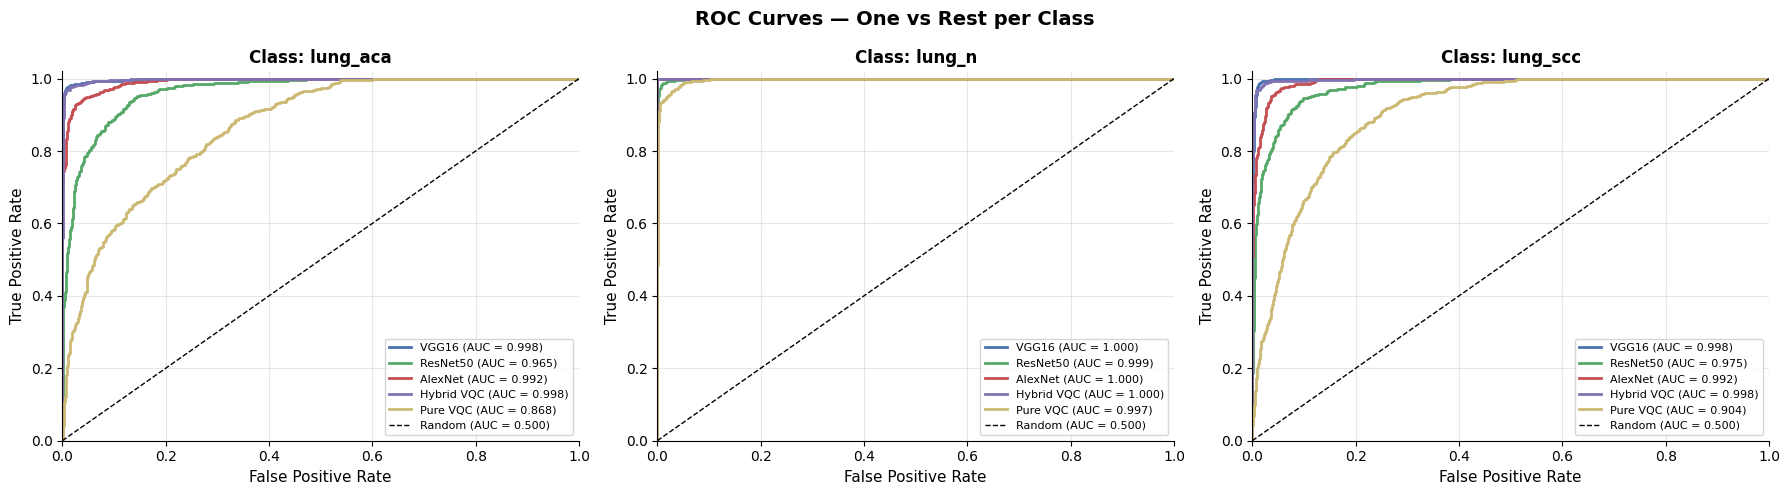


Model            AUC (lung_aca)  AUC (lung_n)  AUC (lung_scc)  Macro AUC
----------------------------------------------------------------------
VGG16            0.998       1.000       0.998       0.999
ResNet50         0.965       0.999       0.975       0.980
AlexNet          0.992       1.000       0.992       0.994
Hybrid VQC       0.998       1.000       0.998       0.999
Pure VQC         0.868       0.997       0.904       0.923


In [32]:
# =============================================
# ROC Curves — all models in one figure
# =============================================
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

class_names = list(test_set.class_indices.keys())
n_classes   = 3

# Binarize true labels for one-vs-rest
y_test_bin = label_binarize(test_set.classes, classes=[0, 1, 2])

# ---- Collect predicted probabilities for each model ----
# Classical models — .predict() gives softmax probs directly
probs_vgg    = vgg_model.predict(test_set)
probs_resnet = resnet_model.predict(test_set)
probs_alex   = alexnet_model.predict(test_set)

# Hybrid VQC
test_X_roc   = jnp.array(test_scaled, dtype=jnp.float64)
probs_hybrid = np.array(forward(weights_jax, test_X_roc))

# Pure VQC
test_pure_roc = jnp.array(test_pixels_scaled, dtype=jnp.float64)
probs_pure_roc = np.array(forward_pure(weights_pure, test_pure_roc))

# ---- Plot ----
models_roc = [
    ("VGG16",       probs_vgg,     "#4C72B0"),
    ("ResNet50",    probs_resnet,  "#55A868"),
    ("AlexNet",     probs_alex,    "#C44E52"),
    ("Hybrid VQC",  probs_hybrid,  "#8172B2"),
    ("Pure VQC",    probs_pure_roc,"#CCB974"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("ROC Curves — One vs Rest per Class",
             fontsize=14, fontweight='bold')

for cls_idx, cls_name in enumerate(class_names):

    ax = axes[cls_idx]

    for model_name, probs, color in models_roc:
        fpr, tpr, _ = roc_curve(
            y_test_bin[:, cls_idx],
            probs[:, cls_idx]
        )
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, linewidth=2,
                label=f"{model_name} (AUC = {roc_auc:.3f})")

    # Random baseline
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')

    ax.set_title(f"Class: {cls_name}", fontsize=12, fontweight='bold')
    ax.set_xlabel("False Positive Rate", fontsize=11)
    ax.set_ylabel("True Positive Rate", fontsize=11)
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150, bbox_inches='tight')
plt.show()

# ---- Print AUC summary table ----
print(f"\n{'Model':<15}", end="")
for c in class_names:
    print(f"  AUC ({c})", end="")
print("  Macro AUC")
print("-" * 70)

for model_name, probs, _ in models_roc:
    aucs = []
    for cls_idx in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, cls_idx], probs[:, cls_idx])
        aucs.append(auc(fpr, tpr))
    print(f"{model_name:<15}", end="")
    for a in aucs:
        print(f"  {a:.3f}     ", end="")
    print(f"  {np.mean(aucs):.3f}")

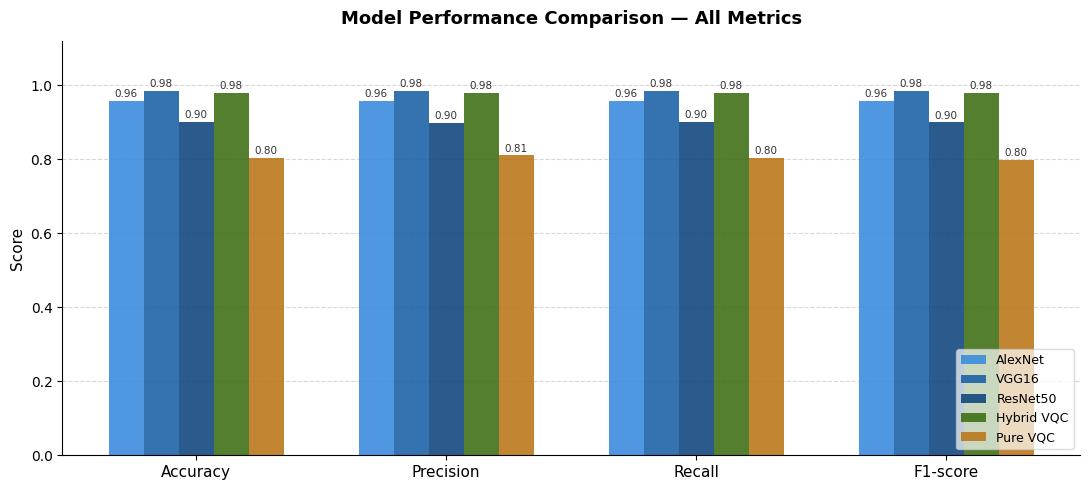

In [34]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ─── Data ───────────────────────────────────────────────────────────────
models = ['AlexNet', 'VGG16', 'ResNet50', 'Hybrid VQC', 'Pure VQC']

metrics = {
    'Accuracy':  [alex_acc,       vgg_acc,       resnet_acc,       accuracy_vqc,  accuracy_pure],
    'Precision': [alex_precision, vgg_precision, resnet_precision, precision_vqc, precision_pure],
    'Recall':    [alex_recall,    vgg_recall,    resnet_recall,    recall_vqc,    recall_pure],
    'F1-score':  [alex_f1,        vgg_f1,        resnet_f1,        f1_vqc,        f1_pure],
}

# Color palette: classical = blue shades, hybrid = green, pure = orange
colors = ['#378ADD', '#185FA5', '#0C447C', '#3B6D11', '#BA7517']

x     = np.arange(len(metrics))
width = 0.14
n     = len(models)
offsets = np.linspace(-(n-1)/2, (n-1)/2, n) * width

# ─── Chart 1: Grouped bar chart ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

for i, (model, color) in enumerate(zip(models, colors)):
    vals = [metrics[m][i] for m in metrics]
    bars = ax.bar(x + offsets[i], vals, width, label=model, color=color, alpha=0.88)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{v:.2f}', ha='center', va='bottom', fontsize=7.5, color='#333')

ax.set_xticks(x)
ax.set_xticklabels(list(metrics.keys()), fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Model Performance Comparison — All Metrics', fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=9, framealpha=0.7)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig1_grouped_bar.png', dpi=200, bbox_inches='tight')
plt.show()

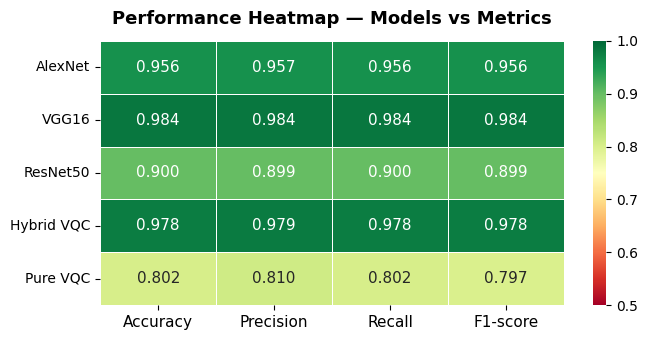

In [36]:
# ─── Chart 3: Metric heatmap table ──────────────────────────────────────
import seaborn as sns
import pandas as pd

heatmap_data = pd.DataFrame(metrics, index=models)

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    vmin=0.5,
    vmax=1.0,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 11}
)
ax.set_title('Performance Heatmap — Models vs Metrics', fontsize=13, fontweight='bold', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=10, rotation=0)
plt.tight_layout()
plt.savefig('fig3_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

71/71 ━━━━━━━━━━━━━━━━━━━━ 20s 274ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 157ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 133ms/step


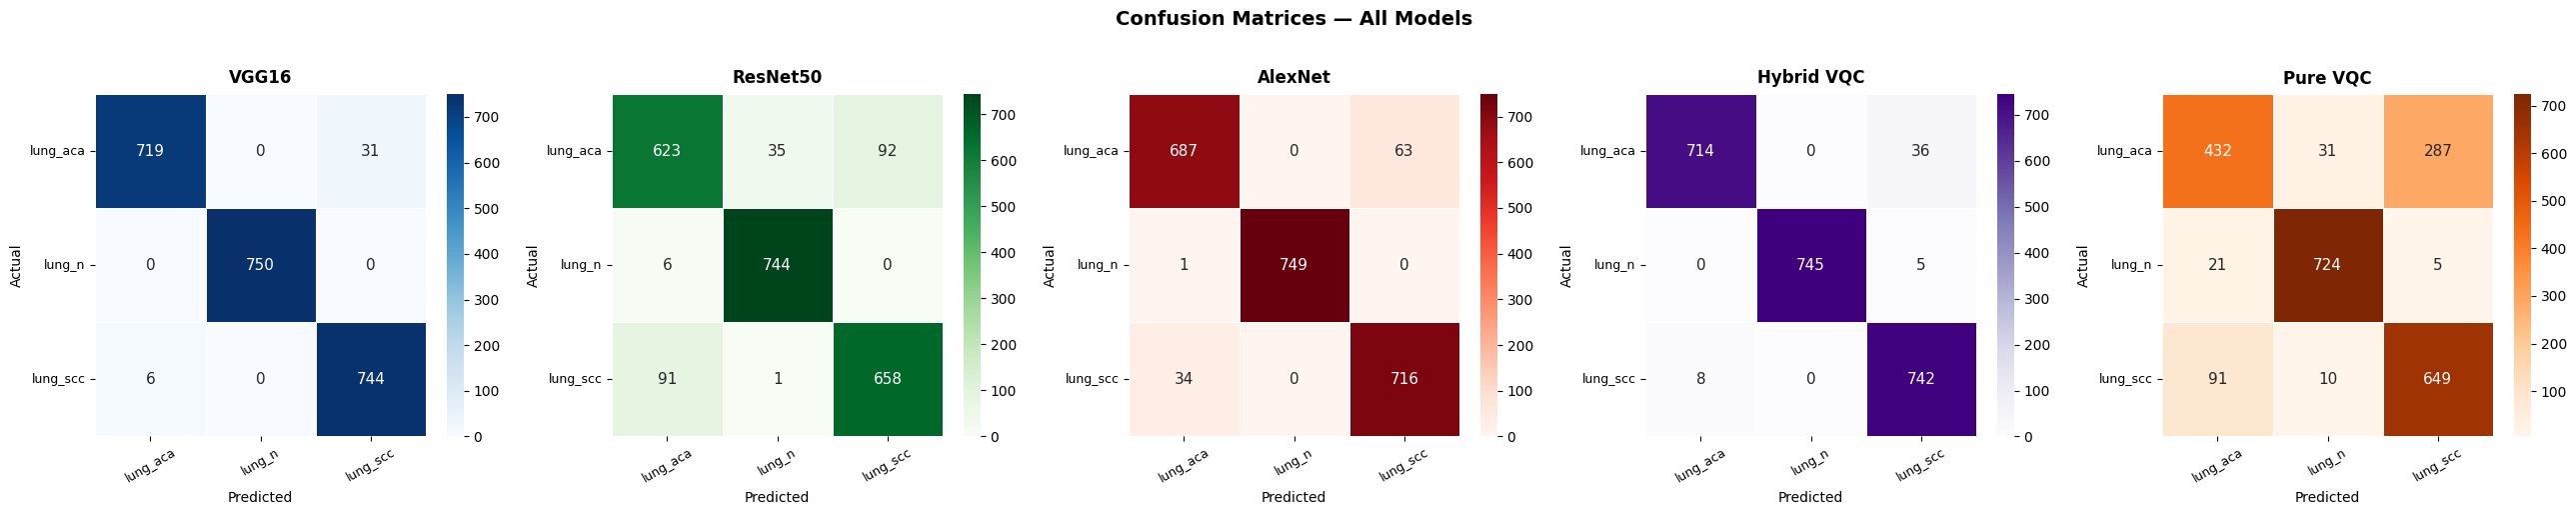

In [37]:
# ─── All 5 confusion matrices in one figure ─────────────────────────────
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

class_names = list(test_set.class_indices.keys())   # ['lung_aca', 'lung_n', 'lung_scc']

# Recompute all matrices (safe even if already computed)
cm_vgg    = confusion_matrix(test_set.classes, np.argmax(vgg_model.predict(test_set),     axis=1))
cm_resnet = confusion_matrix(test_set.classes, np.argmax(resnet_model.predict(test_set),  axis=1))
cm_alex   = confusion_matrix(test_set.classes, np.argmax(alexnet_model.predict(test_set), axis=1))

vqc_probs  = np.array(forward(weights_jax, jnp.array(test_scaled, dtype=jnp.float64)))
cm_vqc     = confusion_matrix(y_test,       np.argmax(vqc_probs, axis=1))

probs_pure = np.array(forward_pure(weights_pure, jnp.array(test_pixels_scaled, dtype=jnp.float64)))
cm_pure    = confusion_matrix(y_test_pure,  np.argmax(probs_pure, axis=1))

cms    = [cm_vgg,   cm_resnet,  cm_alex,   cm_vqc,        cm_pure]
titles = ['VGG16',  'ResNet50', 'AlexNet', 'Hybrid VQC',  'Pure VQC']
cmaps  = ['Blues',  'Greens',   'Reds',    'Purples',      'Oranges']

fig, axes = plt.subplots(1, 5, figsize=(26, 5))
fig.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.02)

for ax, cm, title, cmap in zip(axes, cms, titles, cmaps):
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=cmap,
        xticklabels=class_names, yticklabels=class_names,
        ax=ax, linewidths=0.5, cbar=True, annot_kws={'size': 11}
    )
    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)
    ax.tick_params(axis='x', rotation=30, labelsize=9)
    ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
plt.savefig('fig4_confusion_matrices.png', dpi=200, bbox_inches='tight')
plt.show()

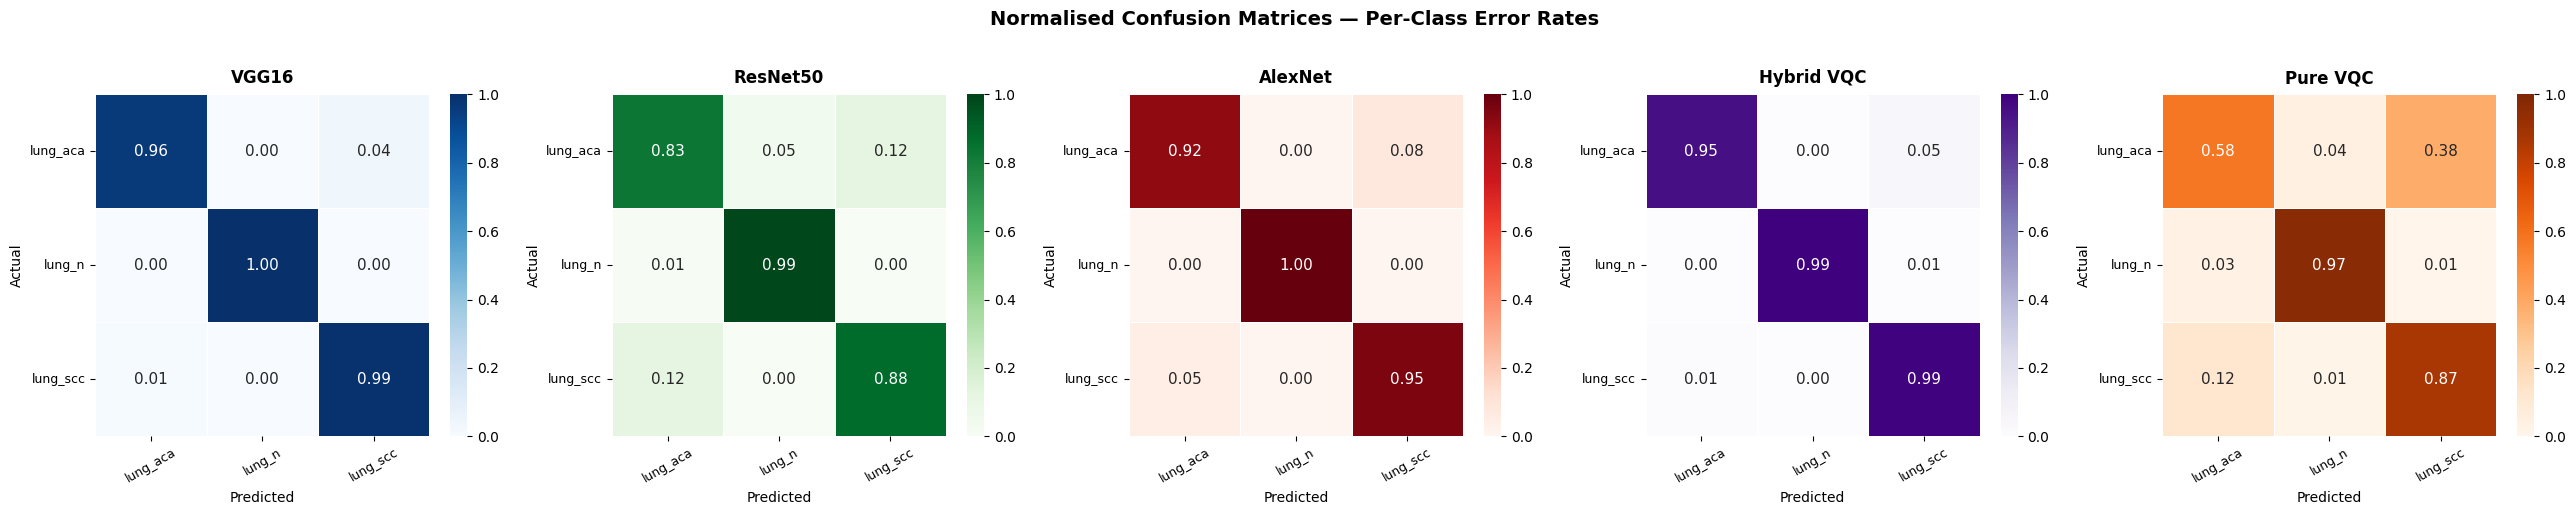

In [38]:
# ─── Normalised confusion matrices (percentages) ────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(26, 5))
fig.suptitle('Normalised Confusion Matrices — Per-Class Error Rates', fontsize=14, fontweight='bold', y=1.02)

for ax, cm, title, cmap in zip(axes, cms, titles, cmaps):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', cmap=cmap,
        xticklabels=class_names, yticklabels=class_names,
        ax=ax, linewidths=0.5, vmin=0, vmax=1, cbar=True,
        annot_kws={'size': 11}
    )
    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)
    ax.tick_params(axis='x', rotation=30, labelsize=9)
    ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
plt.savefig('fig5_confusion_normalised.png', dpi=200, bbox_inches='tight')
plt.show()

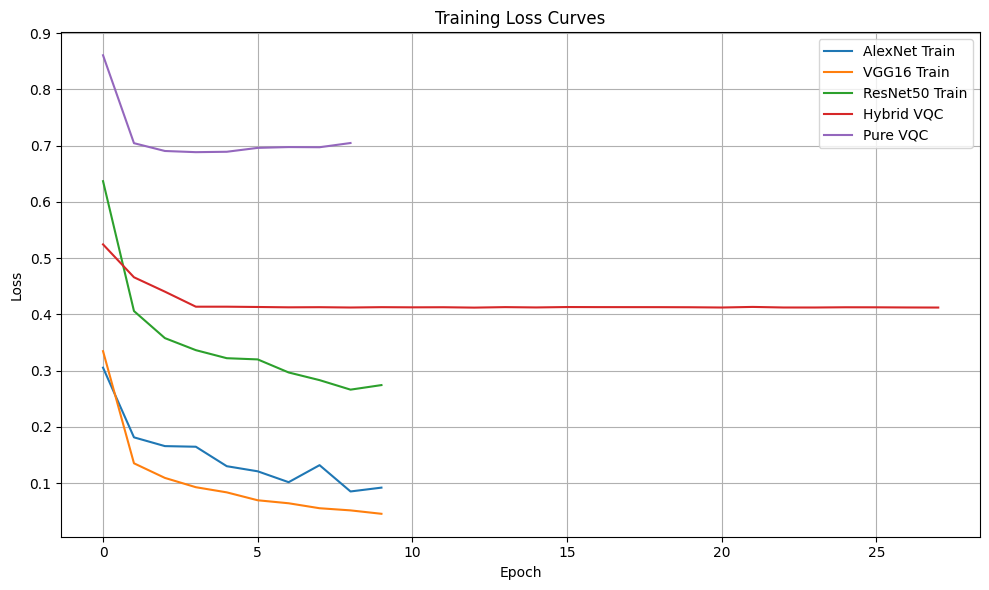

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# AlexNet
plt.plot(
    history_alex.history['loss'],
    label='AlexNet Train'
)

# VGG16
plt.plot(
    history.history['loss'],
    label='VGG16 Train'
)

# ResNet50
plt.plot(
    history_resnet.history['loss'],
    label='ResNet50 Train'
)

# Hybrid VQC
plt.plot(
    vqc_hybrid_epoch_losses,
    label='Hybrid VQC'
)

# Pure VQC
plt.plot(
    vqc_pure_epoch_losses,
    label='Pure VQC'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

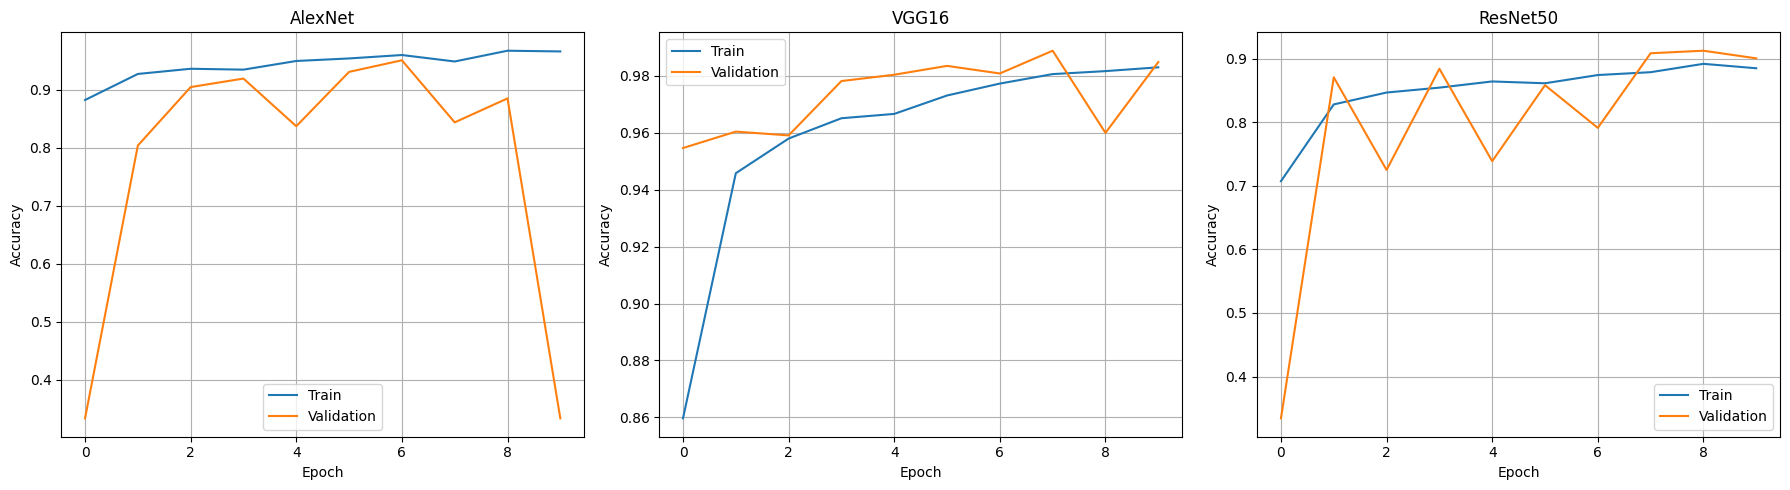

In [52]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

# AlexNet
axes[0].plot(history_alex.history['accuracy'], label='Train')
axes[0].plot(history_alex.history['val_accuracy'], label='Validation')
axes[0].set_title("AlexNet")
axes[0].legend()

# VGG16
axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title("VGG16")
axes[1].legend()

# ResNet50
axes[2].plot(history_resnet.history['accuracy'], label='Train')
axes[2].plot(history_resnet.history['val_accuracy'], label='Validation')
axes[2].set_title("ResNet50")
axes[2].legend()

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.grid(True)

plt.tight_layout()
plt.show()

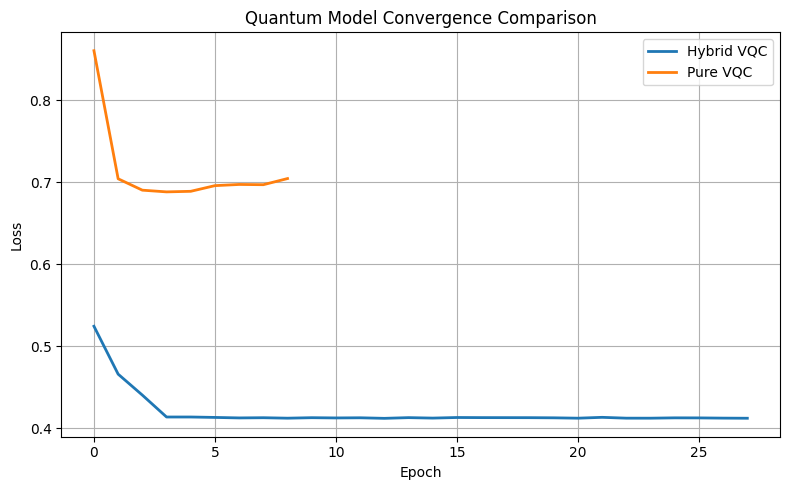

In [53]:
plt.figure(figsize=(8,5))

plt.plot(
    vqc_hybrid_epoch_losses,
    linewidth=2,
    label='Hybrid VQC'
)

plt.plot(
    vqc_pure_epoch_losses,
    linewidth=2,
    label='Pure VQC'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Quantum Model Convergence Comparison")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

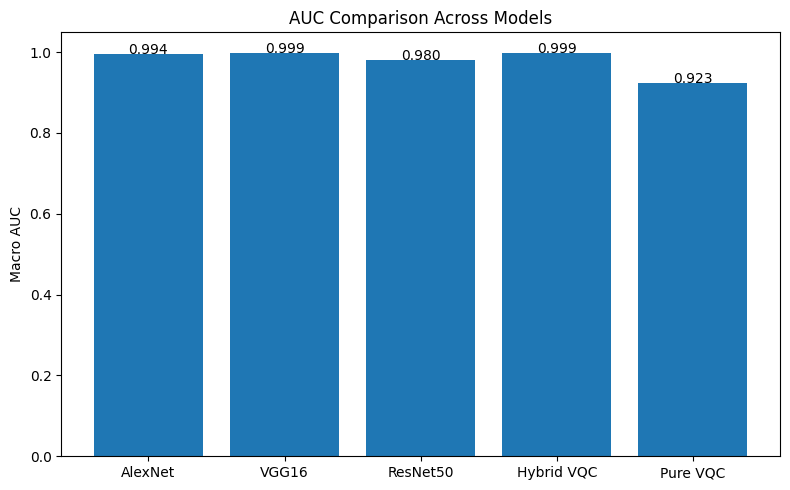

In [54]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(
    test_set.classes,
    classes=[0,1,2]
)

models = {
    "AlexNet": probs_alex,
    "VGG16": probs_vgg,
    "ResNet50": probs_resnet,
    "Hybrid VQC": probs_hybrid,
    "Pure VQC": probs_pure_roc
}

model_names = []
macro_aucs  = []

for name, probs in models.items():

    aucs = []

    for i in range(3):
        aucs.append(
            roc_auc_score(
                y_test_bin[:,i],
                probs[:,i]
            )
        )

    model_names.append(name)
    macro_aucs.append(np.mean(aucs))

plt.figure(figsize=(8,5))

bars = plt.bar(
    model_names,
    macro_aucs
)

plt.ylabel("Macro AUC")
plt.title("AUC Comparison Across Models")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.3f}",
        ha='center'
    )

plt.tight_layout()
plt.show()

/tmp/ipykernel_1539/2041542204.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


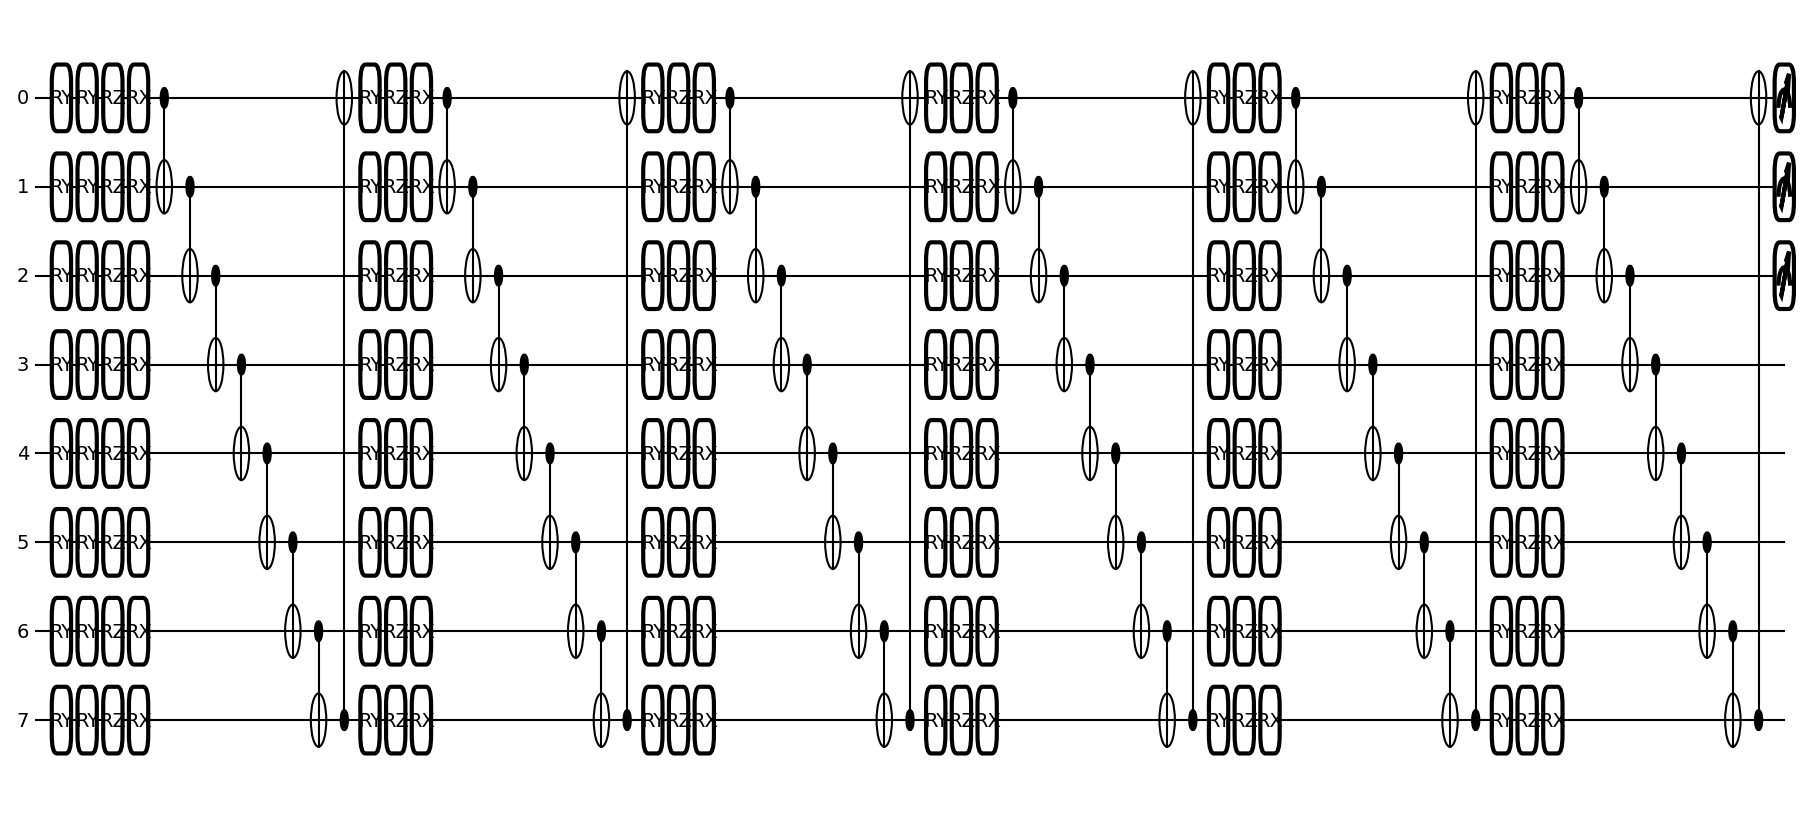

In [56]:
import pennylane as qml
import matplotlib.pyplot as plt

fig, ax = qml.draw_mpl(
    quantum_circuit_pure,
    expansion_strategy="device"
)(
    train_pure_full[0],
    weights_pure
)

fig.set_size_inches(18, 8)
plt.tight_layout()
plt.show()